# Phase II: Cyanobacteria Abundance Forecasting

*Course project of **STATS 402: Interdisciplinary Data Analysis**.*

**Name:** Ziyue Yin

**NetID:** zy166

**How to use this Notebook *wisely*?**

## Prerequisite

Before we continue, please make sure that the following files exist in the corresponding path:
- ILW：`/dkucc/home/zy166/HAB-forecasting/datasets/processed/lake_ci_daily.parquet`
- Daymet：`/dkucc/home/zy166/HAB-forecasting/datasets/Daymet/daymet_glakes_daily.parquet`

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 120

ROOT = Path("/dkucc/home/zy166/HAB-forecasting")

P_ILW    = ROOT / "datasets/processed/lake_ci_daily.parquet"
P_DAYMET = ROOT / "datasets/Daymet/daymet_glakes_daily.parquet"

print(P_ILW)
print(P_DAYMET)

/dkucc/home/zy166/HAB-forecasting/datasets/processed/lake_ci_daily.parquet
/dkucc/home/zy166/HAB-forecasting/datasets/Daymet/daymet_glakes_daily.parquet


Now, we read and merge the preprocessed ILW and Daymet data.

In [2]:
# 读取 ILW 和 Daymet
df_ilw = pd.read_parquet(P_ILW)
df_daymet = pd.read_parquet(P_DAYMET)

# 确保日期是 datetime
df_ilw["date"] = pd.to_datetime(df_ilw["date"])
df_daymet["date"] = pd.to_datetime(df_daymet["date"])

print("ILW columns:", df_ilw.columns.tolist())
print("Daymet columns:", df_daymet.columns.tolist())
print("ILW head:")
display(df_ilw.head())
print("Daymet head:")
display(df_daymet.head())

ILW columns: ['lake_id', 'date', 'product', 'CI_mean', 'CI_p90', 'n_valid', 'src', 'engine']
Daymet columns: ['lake_id', 'lake_name', 'date', 'tmin', 'tmax', 'prcp', 'srad', 'vp', 'dayl']
ILW head:


,lake_id,date,product,CI_mean,CI_p90,n_valid,src,engine
0,GL-1,2024-01-01 13:52:31+00:00,daily,0.000050,0.00005,4140,S3M_OLCI_EFRNT.20240101.L3m.DAY.ILW_CONUS.V5.a...,netcdf4
1,GL-1,2024-01-02 13:36:49+00:00,daily,0.000052,0.00005,763,S3M_OLCI_EFRNT.20240102.L3m.DAY.ILW_CONUS.V5.a...,netcdf4
2,GL-1,2024-01-03 14:02:06+00:00,daily,NaN,NaN,0,S3M_OLCI_EFRNT.20240103.L3m.DAY.ILW_CONUS.V5.a...,netcdf4
3,GL-1,2024-01-04 13:40:26+00:00,daily,0.000052,0.00005,24332,S3M_OLCI_EFRNT.20240104.L3m.DAY.ILW_CONUS.V5.a...,netcdf4
4,GL-1,2024-01-05 13:48:41+00:00,daily,0.000095,0.00005,887,S3M_OLCI_EFRNT.20240105.L3m.DAY.ILW_CONUS.V5.a...,netcdf4


Daymet head:


,lake_id,lake_name,date,tmin,tmax,prcp,srad,vp,dayl
0,GL-1,Erie,2024-01-01 12:00:00,-0.203859,2.958577,0.365888,102.113113,602.591919,32349.982422
1,GL-1,Erie,2024-01-02 12:00:00,-0.614141,2.104940,0.032669,89.671196,584.490723,32394.982422
2,GL-1,Erie,2024-01-03 12:00:00,0.070455,2.292327,1.025123,72.518929,613.914124,32443.656250
3,GL-1,Erie,2024-01-04 12:00:00,-3.859408,0.760503,0.000000,146.215637,460.223694,32495.972656
4,GL-1,Erie,2024-01-05 12:00:00,-4.978480,0.059113,0.000000,156.474442,422.685303,32551.880859


In [4]:
# 统一日期列：去时区 + 只保留日期（设为当天 00:00）
df_ilw["date"] = pd.to_datetime(df_ilw["date"]).dt.tz_localize(None).dt.normalize()
df_daymet["date"] = pd.to_datetime(df_daymet["date"]).dt.tz_localize(None).dt.normalize()

print(df_ilw["date"].dtype, df_daymet["date"].dtype)
print(df_ilw["date"].head())
print(df_daymet["date"].head())

datetime64[ns] datetime64[ns]
0   2024-01-01
1   2024-01-02
3   2024-01-04
4   2024-01-05
5   2024-01-06
Name: date, dtype: datetime64[ns]
0   2024-01-01
1   2024-01-02
2   2024-01-03
3   2024-01-04
4   2024-01-05
Name: date, dtype: datetime64[ns]


In [5]:
# 只保留 ILW 中有有效像元的观测
df_ilw = df_ilw.copy()
df_ilw = df_ilw[df_ilw["n_valid"].fillna(0) > 0]

# 有 product 列的话，也可以只选 daily
if "product" in df_ilw.columns:
    df_ilw = df_ilw[df_ilw["product"] == "daily"]

# 合并成一个 panel：lake_id × date
df = (
    df_ilw.merge(
        df_daymet,
        on=["lake_id", "date"],
        how="inner",
        suffixes=("_ilw", "_daymet"),
    )
)

print("Merged shape:", df.shape)
display(df.head())

Merged shape: (1698, 15)


,lake_id,date,product,CI_mean,CI_p90,n_valid,src,engine,lake_name,tmin,tmax,prcp,srad,vp,dayl
0,GL-1,2024-01-01,daily,0.000050,0.00005,4140,S3M_OLCI_EFRNT.20240101.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-0.203859,2.958577,0.365888,102.113113,602.591919,32349.982422
1,GL-1,2024-01-02,daily,0.000052,0.00005,763,S3M_OLCI_EFRNT.20240102.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-0.614141,2.104940,0.032669,89.671196,584.490723,32394.982422
2,GL-1,2024-01-04,daily,0.000052,0.00005,24332,S3M_OLCI_EFRNT.20240104.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-3.859408,0.760503,0.000000,146.215637,460.223694,32495.972656
3,GL-1,2024-01-05,daily,0.000095,0.00005,887,S3M_OLCI_EFRNT.20240105.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-4.978480,0.059113,0.000000,156.474442,422.685303,32551.880859
4,GL-1,2024-01-06,daily,0.000050,0.00005,7,S3M_OLCI_EFRNT.20240106.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,Erie,-3.090726,2.353635,2.988052,148.110809,486.841797,32611.357422


Feature Engineering (Seasonality, Feature List)

In [6]:
# 添加 day-of-year & seasonality
df = df.copy()
df["doy"] = df["date"].dt.dayofyear
df["sin_doy"] = np.sin(2 * np.pi * df["doy"] / 365.25)
df["cos_doy"] = np.cos(2 * np.pi * df["doy"] / 365.25)

# Daymet 的气象变量（看一下实际有哪些）
daymet_vars = ["tmin", "tmax", "prcp", "srad", "vp", "dayl"]
daymet_vars = [v for v in daymet_vars if v in df.columns]

print("Daymet features:", daymet_vars)

# 特征列表：Daymet + seasonality
FEATURES = daymet_vars + ["sin_doy", "cos_doy"]

# 目标：用 CI_p90 做「蓝藻丰度」代表
TARGET = "CI_p90"   # 你想改成 CI_mean 就改这一行

# 只保留相关列 & 去掉 NaN
cols_needed = ["lake_id", "date", "lake_name"] + [c for c in ["product","n_valid","src","engine"] if c in df.columns]
cols_needed += [TARGET] + FEATURES
cols_needed = list(dict.fromkeys(cols_needed))  # 去重

df_mod = df[cols_needed].copy()
df_mod = df_mod.dropna(subset=[TARGET] + FEATURES)

print("After cleaning:", df_mod.shape)
display(df_mod.head())

Daymet features: ['tmin', 'tmax', 'prcp', 'srad', 'vp', 'dayl']
After cleaning: (1698, 16)


,lake_id,date,lake_name,product,n_valid,src,engine,CI_p90,tmin,tmax,prcp,srad,vp,dayl,sin_doy,cos_doy
0,GL-1,2024-01-01,Erie,daily,4140,S3M_OLCI_EFRNT.20240101.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,0.00005,-0.203859,2.958577,0.365888,102.113113,602.591919,32349.982422,0.017202,0.999852
1,GL-1,2024-01-02,Erie,daily,763,S3M_OLCI_EFRNT.20240102.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,0.00005,-0.614141,2.104940,0.032669,89.671196,584.490723,32394.982422,0.034398,0.999408
2,GL-1,2024-01-04,Erie,daily,24332,S3M_OLCI_EFRNT.20240104.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,0.00005,-3.859408,0.760503,0.000000,146.215637,460.223694,32495.972656,0.068755,0.997634
3,GL-1,2024-01-05,Erie,daily,887,S3M_OLCI_EFRNT.20240105.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,0.00005,-4.978480,0.059113,0.000000,156.474442,422.685303,32551.880859,0.085906,0.996303
4,GL-1,2024-01-06,Erie,daily,7,S3M_OLCI_EFRNT.20240106.L3m.DAY.ILW_CONUS.V5.a...,netcdf4,0.00005,-3.090726,2.353635,2.988052,148.110809,486.841797,32611.357422,0.103031,0.994678


Small utility functions

In [7]:
def plot_bar(series, title, xlabel="Coefficient / Importance"):
    """
    series: pd.Series, index = feature names
    """
    series = series.sort_values()
    plt.figure()
    plt.barh(series.index, series.values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.tight_layout()
    plt.show()

## 单湖模型：线性回归 + Random Forest

逐湖拟合 & 收集结果

In [9]:
results_lake_level = []       # 存 R^2 / RMSE 等 summary
coef_lake_level = []          # 存线性模型系数
rf_importance_lake_level = [] # 存 RF 特征重要性

min_samples = 50  # 每个湖至少多少条数据才建模，可按需要调

for lake_id, df_lake in df_mod.groupby("lake_id"):
    if len(df_lake) < min_samples:
        print(f"[SKIP] lake {lake_id}: too few samples ({len(df_lake)})")
        continue

    lake_name = df_lake["lake_name"].iloc[0] if "lake_name" in df_lake else str(lake_id)

    X = df_lake[FEATURES].values
    y_raw = df_lake[TARGET].values
    y = np.log1p(y_raw)  # log1p 变换缓解偏态

    # --- 线性模型（带标准化） ---
    pipe_lin = make_pipeline(
        StandardScaler(),
        LinearRegression()
    )
    pipe_lin.fit(X, y)
    y_pred_lin = pipe_lin.predict(X)

    r2_lin = r2_score(y, y_pred_lin)
    rmse_lin = np.sqrt(mean_squared_error(y, y_pred_lin))

    # 拿到标准化后的系数
    lin = pipe_lin.named_steps["linearregression"]
    coefs = lin.coef_
    coef_df = pd.DataFrame({
        "lake_id": lake_id,
        "lake_name": lake_name,
        "feature": FEATURES,
        "coef": coefs,
    })
    coef_lake_level.append(coef_df)

    # --- Random Forest ---
    rf = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=3,
    )
    rf.fit(X, y)
    y_pred_rf = rf.predict(X)

    r2_rf = r2_score(y, y_pred_rf)
    rmse_rf = np.sqrt(mean_squared_error(y, y_pred_rf))

    rf_imp_df = pd.DataFrame({
        "lake_id": lake_id,
        "lake_name": lake_name,
        "feature": FEATURES,
        "importance": rf.feature_importances_,
    })
    rf_importance_lake_level.append(rf_imp_df)

    # 汇总结果
    results_lake_level.append({
        "lake_id": lake_id,
        "lake_name": lake_name,
        "n_samples": len(df_lake),
        "r2_lin": r2_lin,
        "rmse_lin": rmse_lin,
        "r2_rf": r2_rf,
        "rmse_rf": rmse_rf,
    })

    print(f"[OK] lake {lake_id} ({lake_name}): "
          f"R2_lin={r2_lin:.3f}, R2_rf={r2_rf:.3f}, n={len(df_lake)}")

# 拼成 DataFrame
results_lake_level = pd.DataFrame(results_lake_level)
coef_lake_level = pd.concat(coef_lake_level, ignore_index=True)
rf_importance_lake_level = pd.concat(rf_importance_lake_level, ignore_index=True)

display(results_lake_level)

[OK] lake GL-1 (Erie): R2_lin=0.195, R2_rf=0.517, n=335
[OK] lake GL-2 (Huron): R2_lin=0.094, R2_rf=0.585, n=342
[OK] lake GL-3 (Michigan): R2_lin=0.034, R2_rf=0.332, n=345
[OK] lake GL-4 (Ontario): R2_lin=0.019, R2_rf=0.415, n=325
[OK] lake GL-5 (Superior): R2_lin=0.011, R2_rf=0.300, n=351


,lake_id,lake_name,n_samples,r2_lin,rmse_lin,r2_rf,rmse_rf
0,GL-1,Erie,335,0.194675,0.001268,0.516775,0.000982
1,GL-2,Huron,342,0.094468,0.000355,0.585329,0.000240
2,GL-3,Michigan,345,0.034136,0.000331,0.332314,0.000275
3,GL-4,Ontario,325,0.018587,0.000308,0.415258,0.000238
4,GL-5,Superior,351,0.011097,0.000153,0.299783,0.000129


查看单湖的系数 & 特征重要性

In [10]:
# 看看都有哪些湖
results_lake_level

,lake_id,lake_name,n_samples,r2_lin,rmse_lin,r2_rf,rmse_rf
0,GL-1,Erie,335,0.194675,0.001268,0.516775,0.000982
1,GL-2,Huron,342,0.094468,0.000355,0.585329,0.000240
2,GL-3,Michigan,345,0.034136,0.000331,0.332314,0.000275
3,GL-4,Ontario,325,0.018587,0.000308,0.415258,0.000238
4,GL-5,Superior,351,0.011097,0.000153,0.299783,0.000129


  lake_id lake_name
0    GL-1      Erie


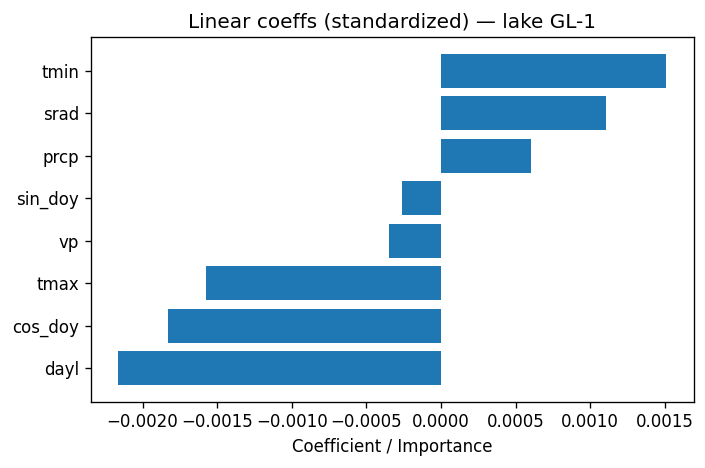

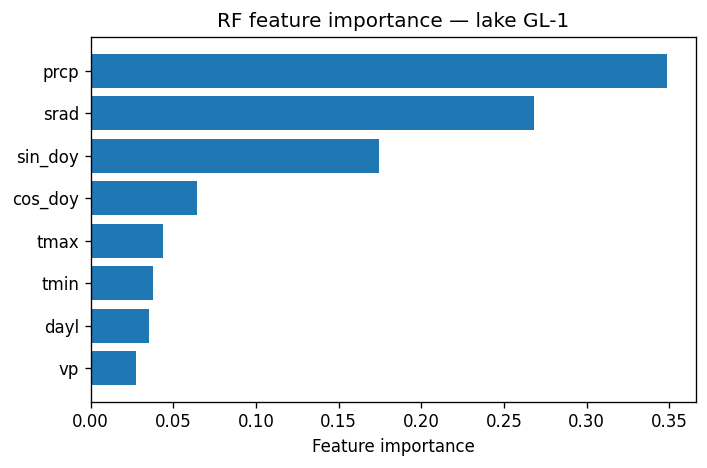

In [11]:
# 示例：选一个湖（比如苏必利尔湖的 lake_id）
example_lake_id = results_lake_level["lake_id"].iloc[0]

sub_coef = coef_lake_level[coef_lake_level["lake_id"] == example_lake_id]
sub_rf   = rf_importance_lake_level[rf_importance_lake_level["lake_id"] == example_lake_id]

print(sub_coef[["lake_id","lake_name"]].drop_duplicates())
plot_bar(sub_coef.set_index("feature")["coef"],
         title=f"Linear coeffs (standardized) — lake {example_lake_id}")

plot_bar(sub_rf.set_index("feature")["importance"],
         title=f"RF feature importance — lake {example_lake_id}",
         xlabel="Feature importance")

## 合并 5 湖的整体模型

全湖合并模型（线性 + RF）

[GLOBAL] Linear: R^2=0.036, RMSE=0.001


,coef
tmin,0.000354
tmax,-0.000378
prcp,0.000122
srad,0.000233
vp,-0.000057
dayl,-0.000609
sin_doy,-0.000035
cos_doy,-0.000520


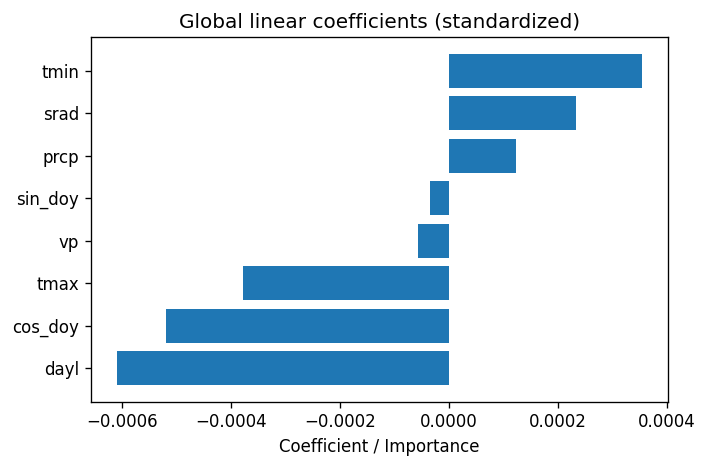

In [13]:
# 全体样本
df_all = df_mod.dropna(subset=[TARGET] + FEATURES).copy()

X_all = df_all[FEATURES].values
y_all = np.log1p(df_all[TARGET].values)

# --- 全局线性模型 ---
pipe_lin_global = make_pipeline(
    StandardScaler(),
    LinearRegression()
)
pipe_lin_global.fit(X_all, y_all)
yhat_lin_global = pipe_lin_global.predict(X_all)

r2_lin_global = r2_score(y_all, yhat_lin_global)
rmse_lin_global = np.sqrt(mean_squared_error(y_all, yhat_lin_global))


lin_global = pipe_lin_global.named_steps["linearregression"]
coefs_global = pd.Series(lin_global.coef_, index=FEATURES)

print(f"[GLOBAL] Linear: R^2={r2_lin_global:.3f}, RMSE={rmse_lin_global:.3f}")
display(coefs_global.to_frame("coef"))
plot_bar(coefs_global, title="Global linear coefficients (standardized)")

[GLOBAL] RF: R^2=0.451, RMSE=0.001


,importance
tmin,0.078530
tmax,0.074223
prcp,0.220039
srad,0.270453
vp,0.091137
dayl,0.088384
sin_doy,0.126805
cos_doy,0.050430


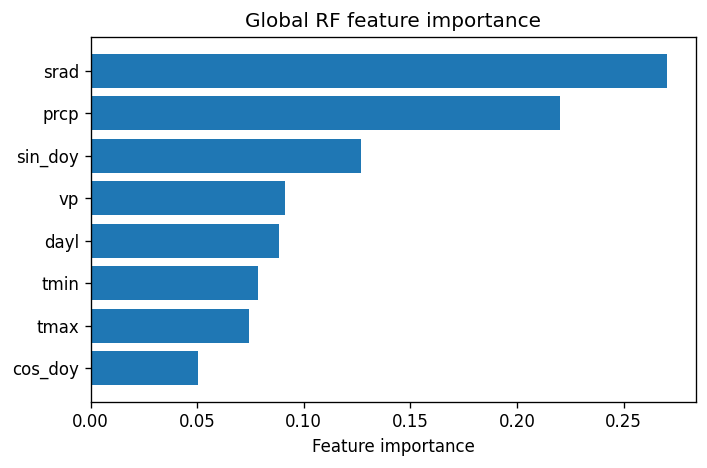

In [14]:
# --- 全局 Random Forest ---
rf_global = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=3,
)
rf_global.fit(X_all, y_all)
yhat_rf_global = rf_global.predict(X_all)

r2_rf_global = r2_score(y_all, yhat_rf_global)
rmse_rf_global = np.sqrt(mean_squared_error(y_all, yhat_rf_global))

rf_importance_global = pd.Series(rf_global.feature_importances_, index=FEATURES)

print(f"[GLOBAL] RF: R^2={r2_rf_global:.3f}, RMSE={rmse_rf_global:.3f}")
display(rf_importance_global.to_frame("importance"))
plot_bar(rf_importance_global, title="Global RF feature importance",
         xlabel="Feature importance")

加上 lake_id one-hot 看「控湖后」的 Daymet 贡献

[GLOBAL + lake dummies] Linear: R^2=0.067, RMSE=0.001


,coef
tmin,0.000238
tmax,-0.000295
prcp,0.000107
srad,0.000148
vp,-0.000117
dayl,-0.000624
sin_doy,-0.000052
cos_doy,-0.000669


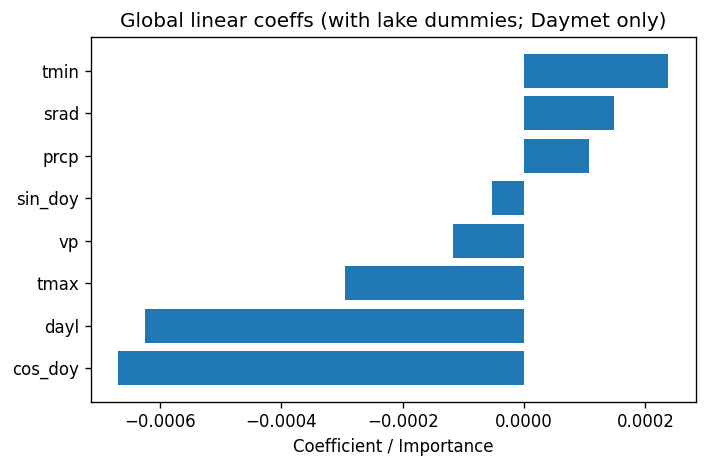

In [15]:
# 将 lake_id 变成 one-hot
lake_dummies = pd.get_dummies(df_all["lake_id"].astype(str), prefix="lake")
X_global_with_lake = np.concatenate(
    [df_all[FEATURES].values, lake_dummies.values],
    axis=1,
)

feature_names_global = FEATURES + lake_dummies.columns.tolist()

pipe_lin_global_lake = make_pipeline(
    StandardScaler(),
    LinearRegression()
)
pipe_lin_global_lake.fit(X_global_with_lake, y_all)
yhat_global_lake = pipe_lin_global_lake.predict(X_global_with_lake)

r2_global_lake = r2_score(y_all, yhat_global_lake)
rmse_global_lake = np.sqrt(mean_squared_error(y_all, yhat_global_lake))

lin_gl = pipe_lin_global_lake.named_steps["linearregression"]
coefs_gl = pd.Series(lin_gl.coef_, index=feature_names_global)

print(f"[GLOBAL + lake dummies] Linear: R^2={r2_global_lake:.3f}, RMSE={rmse_global_lake:.3f}")

# 只看 Daymet + seasonality 的系数部分
coefs_daymet_only = coefs_gl[FEATURES]
display(coefs_daymet_only.to_frame("coef"))
plot_bar(coefs_daymet_only,
         title="Global linear coeffs (with lake dummies; Daymet only)")